# Summary

Lets fit the models to the actual data.

---
# Setup

In [1]:
'''monkey = 'po'

behav_full = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))
behav_full = behav_full[:-100_000]  # Remove last 100k rows
# count per model
print(behav_full.model.value_counts())

# save back
behav_full.to_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))'''

"monkey = 'po'\n\nbehav_full = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))\nbehav_full = behav_full[:-100_000]  # Remove last 100k rows\n# count per model\nprint(behav_full.model.value_counts())\n\n# save back\nbehav_full.to_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))"

In [2]:
# @title Imports
import pandas as pd
import matplotlib.pyplot as plt

from popy.plotting.plotting_tools import *
from popy.behavior_data_tools import *
from popy.config import PROJECT_PATH_LOCAL

/home/uzsombi/.config/matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /tmp/matplotlib-hfu0gj0c because there was an issue with the default path (/home/uzsombi/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


---
# Simulated agent behavior

In [3]:
agents_to_show = {
    'recording': 'recording',
    'WSLS': 'WSLS',
    'Standard RL - stickiness': 'Standard RL',
    'Inferential RL - stickiness': 'Inferential RL',
    'Foraging': 'Foraging',
    'HSMMAgent': 'HSMM',
}

# Optimization

['WSLS' 'Repeating agent' 'Standard RL - stickiness' 'Standard RL'
 'Standard RL - forgetting' 'Inferential RL - stickiness + spatial bias'
 'Standard RL - stickiness + forgetting'
 'Inferential RL - stickiness + multiple alphas' 'Foraging'
 'Inferential RL - stickiness' 'Inferential RL' 'Foraging - no reset'
 'Foraging - abandoned bias' 'Foraging - abandoned bias + spatial bias'
 'Foraging - adaptive threshold' 'HSMMAgent']


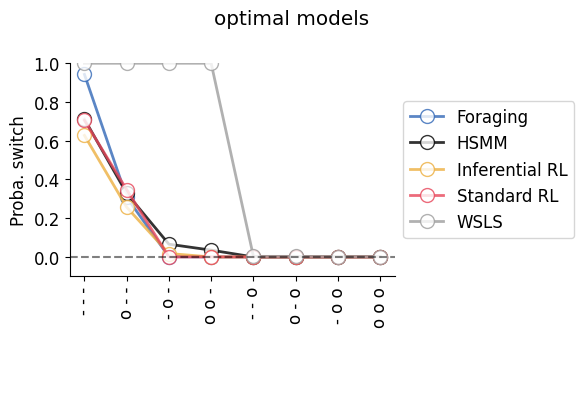

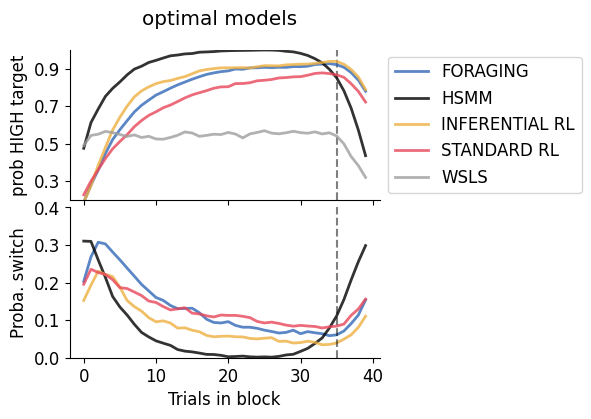

In [4]:
behav = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'optimizing', f'simulation_behaviors.pkl'))
print(behav.model.unique())
# remove n_target_touches column if exists
if 'n_target_touches' in behav.columns:
    behav = behav.drop(columns=['n_target_touches'])
# keep only models in agents_to_show.keys() and renaming them
behav = behav[behav['model'].isin(agents_to_show.keys())].copy()
behav['model'] = behav['model'].map(agents_to_show)
# rename 'recording' to 'monkey'
behav['model'] = behav['model'].replace({'recording': 'sim'})

# Apply the function to create the monkey column
behav['monkey'] = behav['model']

behav = convert_column_format(behav, original='simulation')

behav = add_history_of_feedback(behav, num_trials=3, one_column=False, coding=(0, 1))
behav = add_switch_info(behav, add_trials_since_switch=True, flip_coding=False)
behav = behav.dropna()

fig1, _ = plot_hist_thingy(behav, title=f'optimal models', paper_format=False)
# remove legend
plt.legend([], [], frameon=False)
fig2, _ = plot_strategy(behav, title=f'optimal models', paper_format=False, h=2, w=1.6, ylim=[0, .4], verbose=False)
# remove legend
plt.legend([], [], frameon=False)

# save figs


# Simulation

Processing monkey: ka
['recording' 'WSLS' 'Inferential RL - stickiness' 'Foraging - no reset'
 'Inferential RL - stickiness + spatial bias' 'Repeating agent'
 'Inferential RL' 'Standard RL - forgetting' 'Foraging - abandoned bias'
 'Standard RL - forgetting + stickiness'
 'Foraging - abandoned bias + spatial bias'
 'Inferential RL - stickiness + multiple alphas'
 'Standard RL - stickiness' 'Standard RL' 'Foraging'
 'Foraging - adaptive threshold' 'HSMMAgent']


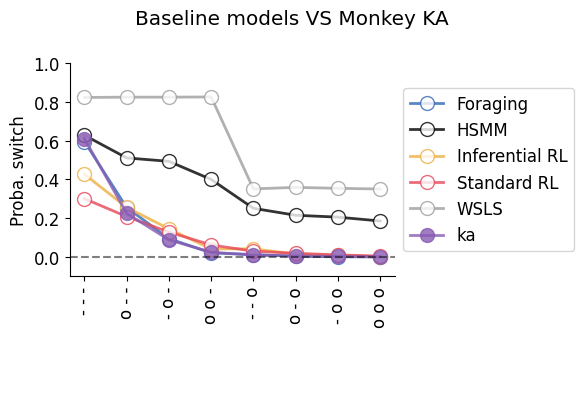

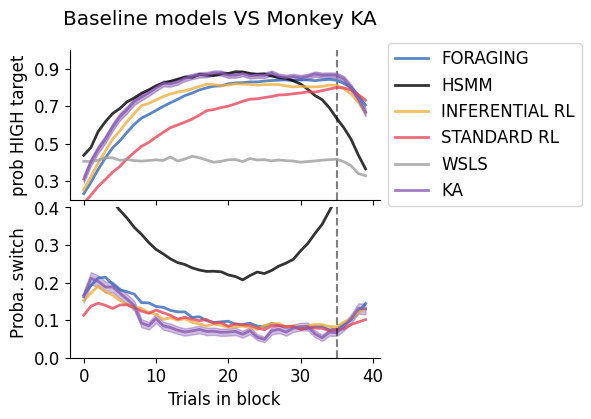

Processing monkey: po
['recording' 'WSLS' 'Inferential RL'
 'Standard RL - forgetting + stickiness'
 'Inferential RL - stickiness + spatial bias' 'Foraging'
 'Standard RL - forgetting' 'Foraging - no reset' 'Repeating agent'
 'Foraging - abandoned bias' 'Foraging - abandoned bias + spatial bias'
 'Standard RL' 'Inferential RL - stickiness'
 'Inferential RL - stickiness + multiple alphas'
 'Foraging - adaptive threshold' 'Standard RL - stickiness' 'HSMMAgent']


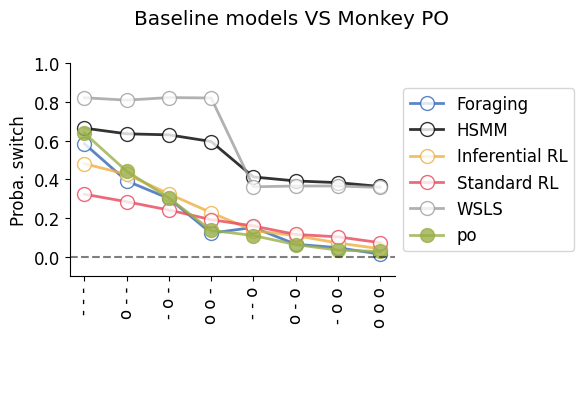

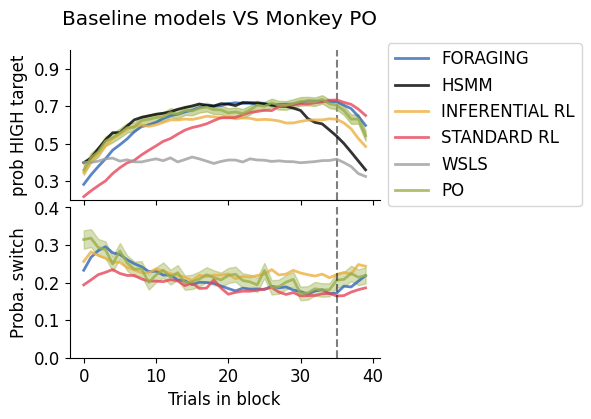

In [5]:
for monkey in ['ka', 'po']:#, 'yu_sham', 'yu_DCZ']:
    print(f'Processing monkey: {monkey}')
    behav = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting_no_cv', f'simulation_behaviors_{monkey}.pkl'))
    print(behav.model.unique())
    # remove n_target_touches column if exists
    if 'n_target_touches' in behav.columns:
        behav = behav.drop(columns=['n_target_touches'])
    # keep only models in agents_to_show.keys() and renaming them
    behav = behav[behav['model'].isin(agents_to_show.keys())].copy()
    behav['model'] = behav['model'].map(agents_to_show)
    # rename 'recording' to 'monkey'
    behav['model'] = behav['model'].replace({'recording': monkey})

    # Apply the function to create the monkey column
    behav['monkey'] = behav['model']

    behav = convert_column_format(behav, original='simulation')

    behav = add_history_of_feedback(behav, num_trials=3, one_column=False, coding=(0, 1))
    behav = add_switch_info(behav, add_trials_since_switch=True, flip_coding=False)
    behav = behav.dropna()

    fig1, _ = plot_hist_thingy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=False)
    # remove legend
    plt.legend([], [], frameon=False)
    fig2, _ = plot_strategy(behav, title=f'Baseline models VS Monkey {monkey.upper()}', paper_format=False, h=2, w=1.6, ylim=[0, .4], verbose=False)
    # remove legend
    plt.legend([], [], frameon=False)

    # save figs
    fig1.savefig(f'figs/behav_modeling_{monkey}_history_thing.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig1)
    fig2.savefig(f'figs/behav_modeling_{monkey}_strategy.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig2)

# Plotting the fitting results on the first 15 trials only against the full fitting

Processing monkey: ka


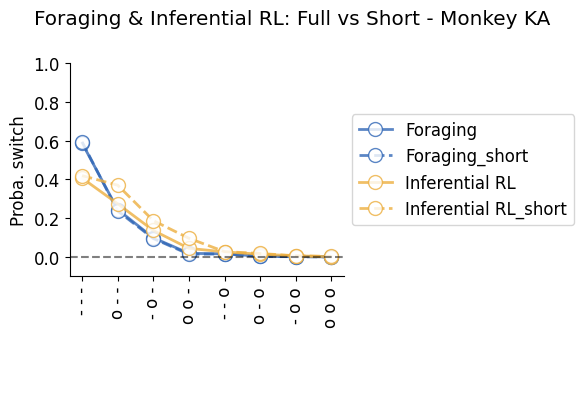

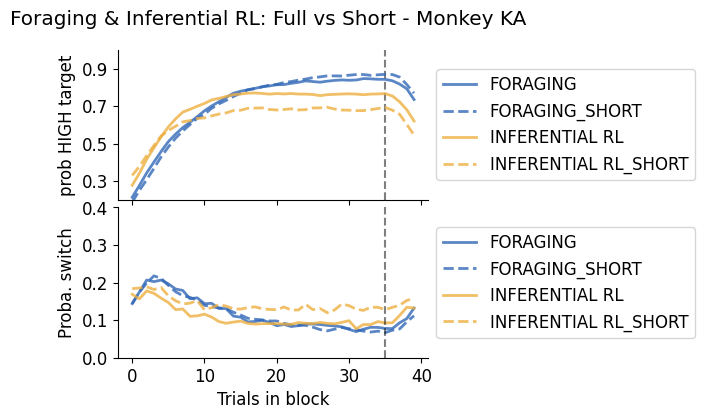

Processing monkey: po


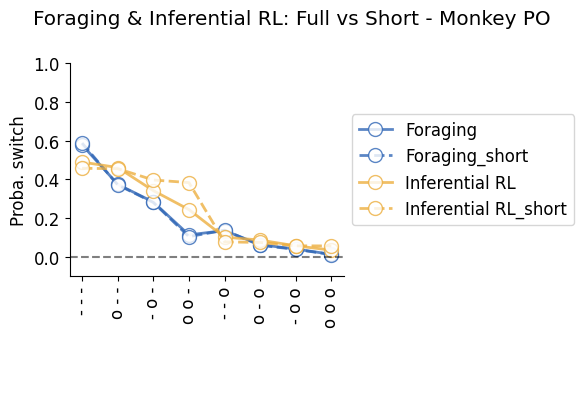

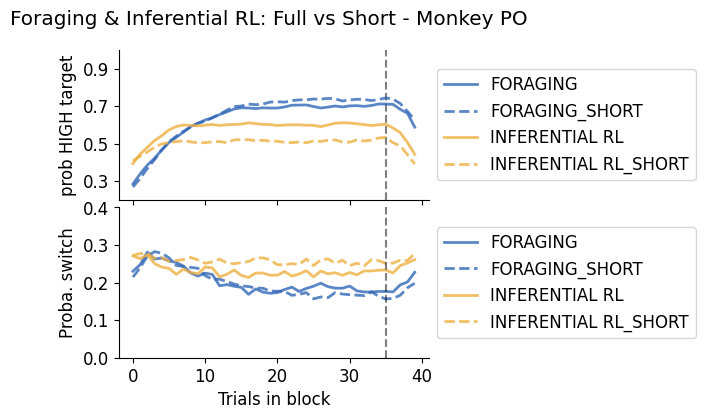

In [6]:
# Filter and prepare data for both model sets
models_to_plot = {
    'Inferential RL - stickiness': 'Inferential RL',
    'Foraging': 'Foraging',
}

for monkey in ['ka', 'po']:
    print(f'Processing monkey: {monkey}')
    
    # Load both datasets
    behav_full = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))
    behav_first15 = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting_first15', f'simulation_behaviors_{monkey}.pkl'))
    
    # Process full dataset
    behav_original = behav_full.copy()
    if 'n_target_touches' in behav_original.columns:
        behav_original = behav_original.drop(columns=['n_target_touches'])
    behav_original = behav_original[behav_original['model'].isin(models_to_plot.keys())].copy()
    behav_original['model'] = behav_original['model'].map(models_to_plot)
    behav_original['monkey'] = behav_original['model']
    behav_original = convert_column_format(behav_original, original='simulation')
    behav_original = add_history_of_feedback(behav_original, num_trials=3, one_column=False, coding=(0, 1))
    behav_original = add_switch_info(behav_original, add_trials_since_switch=True, flip_coding=False)
    behav_original = behav_original.dropna()
    
    # Process the second set of models (fitting_first15) and rename them with _short suffix
    behav_short = behav_first15.copy()
    if 'n_target_touches' in behav_short.columns:
        behav_short = behav_short.drop(columns=['n_target_touches'])
    behav_short = behav_short[behav_short['model'].isin(models_to_plot.keys())].copy()
    behav_short['model'] = behav_short['model'].map(models_to_plot)
    behav_short['model'] = behav_short['model'] + '_short'
    behav_short['monkey'] = behav_short['model']
    behav_short = convert_column_format(behav_short, original='simulation')
    behav_short = add_history_of_feedback(behav_short, num_trials=3, one_column=False, coding=(0, 1))
    behav_short = add_switch_info(behav_short, add_trials_since_switch=True, flip_coding=False)
    behav_short = behav_short.dropna()
    
    # Combine both datasets
    behav_combined = pd.concat([behav_original, behav_short], ignore_index=True)
    
    # Plot
    fig1, _ = plot_hist_thingy(behav_combined, title=f'Foraging & Inferential RL: Full vs Short - Monkey {monkey.upper()}', paper_format=False)
    fig2, _ = plot_strategy(behav_combined, title=f'Foraging & Inferential RL: Full vs Short - Monkey {monkey.upper()}', paper_format=False, h=2, w=1.6, ylim=[0, .4], verbose=False)
    
    # save figs
    fig1.savefig(f'figs/behav_modeling_{monkey}_short_comparison_history.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig1)
    fig2.savefig(f'figs/behav_modeling_{monkey}_short_comparison_strategy.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig2)

# Plotting the fitting results on the first 10 trials only against the full fitting

Processing monkey: ka


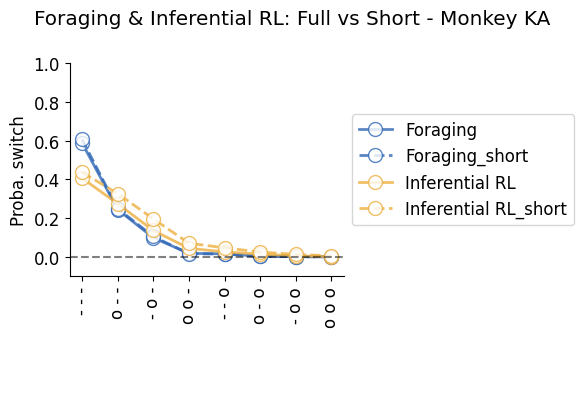

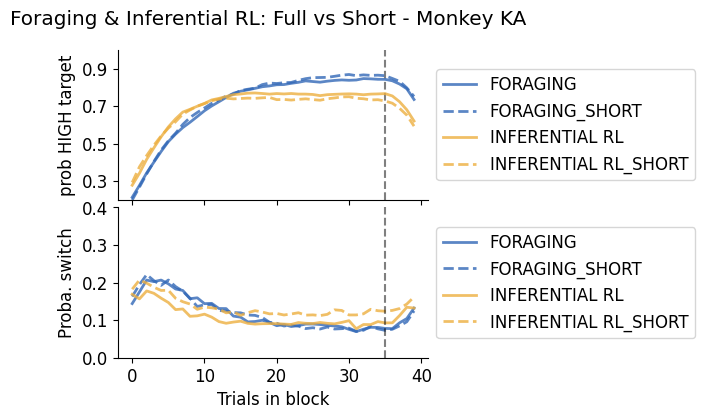

Processing monkey: po


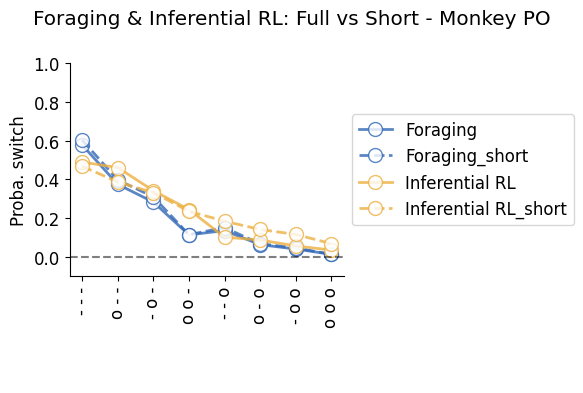

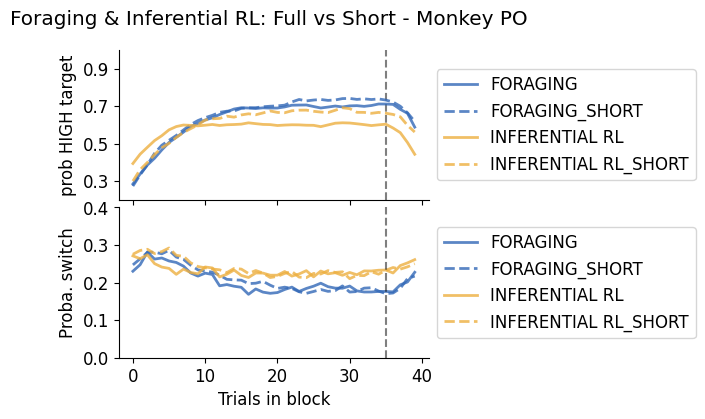

In [7]:
# Filter and prepare data for both model sets
models_to_plot = {
    'Inferential RL - stickiness': 'Inferential RL',
    'Foraging': 'Foraging',
}

for monkey in ['ka', 'po']:
    print(f'Processing monkey: {monkey}')
    
    # Load both datasets
    behav_full = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting', f'simulation_behaviors_{monkey}.pkl'))
    behav_first10 = pd.read_pickle(os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', f'results', 'fitting_first10', f'simulation_behaviors_{monkey}.pkl'))
    
    # Process full dataset
    behav_original = behav_full.copy()
    if 'n_target_touches' in behav_original.columns:
        behav_original = behav_original.drop(columns=['n_target_touches'])
    behav_original = behav_original[behav_original['model'].isin(models_to_plot.keys())].copy()
    behav_original['model'] = behav_original['model'].map(models_to_plot)
    behav_original['monkey'] = behav_original['model']
    behav_original = convert_column_format(behav_original, original='simulation')
    behav_original = add_history_of_feedback(behav_original, num_trials=3, one_column=False, coding=(0, 1))
    behav_original = add_switch_info(behav_original, add_trials_since_switch=True, flip_coding=False)
    behav_original = behav_original.dropna()
    
    # Process the second set of models (fitting_first10) and rename them with _short suffix
    behav_short = behav_first10.copy()
    if 'n_target_touches' in behav_short.columns:
        behav_short = behav_short.drop(columns=['n_target_touches'])
    behav_short = behav_short[behav_short['model'].isin(models_to_plot.keys())].copy()
    behav_short['model'] = behav_short['model'].map(models_to_plot)
    behav_short['model'] = behav_short['model'] + '_short'
    behav_short['monkey'] = behav_short['model']
    behav_short = convert_column_format(behav_short, original='simulation')
    behav_short = add_history_of_feedback(behav_short, num_trials=3, one_column=False, coding=(0, 1))
    behav_short = add_switch_info(behav_short, add_trials_since_switch=True, flip_coding=False)
    behav_short = behav_short.dropna()
    
    # Combine both datasets
    behav_combined = pd.concat([behav_original, behav_short], ignore_index=True)
    
    # Plot
    fig1, _ = plot_hist_thingy(behav_combined, title=f'Foraging & Inferential RL: Full vs Short - Monkey {monkey.upper()}', paper_format=False)
    fig2, _ = plot_strategy(behav_combined, title=f'Foraging & Inferential RL: Full vs Short - Monkey {monkey.upper()}', paper_format=False, h=2, w=1.6, ylim=[0, .4], verbose=False)
    
    # save figs
    fig1.savefig(f'figs/behav_modeling_{monkey}_short_comparison_history.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig1)
    fig2.savefig(f'figs/behav_modeling_{monkey}_short_comparison_strategy.svg', dpi=300, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close(fig2)